# Tutorial 9 · Newton & Curve Fitting — Part B

**~40 minutes · after the worksheet**

Compare gradient and Newton steps, then fit a nonlinear decay model with Gauss–Newton structure.

Work in pairs. Before each code cell, write down the qualitative result you expect. The notebook is designed to run top-to-bottom in a fresh kernel.


## 1 · Newton's digits double near the solution


In [1]:
import numpy as np
import matplotlib.pyplot as plt

x=.5
for k in range(7):
    print(k, x, "error", abs(x-1))
    x=2*x-x*x


0 0.5 error 0.5
1 0.75 error 0.25
2 0.9375 error 0.0625
3 0.99609375 error 0.00390625
4 0.9999847412109375 error 1.52587890625e-05
5 0.9999999997671694 error 2.3283064365386963e-10
6 1.0 error 0.0


## 2 · Fit exponential decay


[2.37583048 0.53933102] steps 7


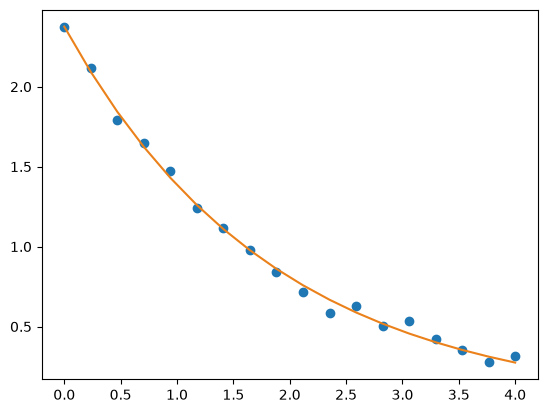

In [2]:
#| fig-alt: 'Noisy exponential-decay observations with the nonlinear least-squares fitted curve overlaid.'
from scipy.optimize import least_squares
rng=np.random.default_rng(9)
t=np.linspace(0,4,18); y=2.4*np.exp(-.55*t)+rng.normal(0,.035,len(t))
def residual(params):
    a,b=params; return a*np.exp(-b*t)-y
def jac(params):
    a,b=params; e=np.exp(-b*t); return np.column_stack([e,-a*t*e])
fit=least_squares(residual,[1,.2],jac=jac,method="lm")
print(fit.x, "steps", fit.nfev)
plt.scatter(t,y); plt.plot(t,fit.x[0]*np.exp(-fit.x[1]*t),color="#EB811B");


## 3 · Inspect the Gauss–Newton curvature


In [3]:
J=jac(fit.x); print("J.T J =\n",J.T@J); print("condition number",np.linalg.cond(J.T@J))


J.T J =
 [[ 4.41491342 -8.07660635]
 [-8.07660635 31.34378645]]
condition number 15.415791133827005


## Closing check

Write three sentences: one numerical result you verified, one geometric/probabilistic interpretation, and one failure mode you would now test in a larger implementation.
